<a href="https://colab.research.google.com/github/Ziyi-star/Bachelorarbeit/blob/main/notebooks/training/train_1s_30hz_initial_2class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Field validation test and analyse 1s 100hz

In [ ]:
# Author: Ziyi Liu
# Project: Bachelor's Thesis - Cyclist Curb Detection under Varying Road Roughness
# Institution: Universität Kassel
# License: GNU General Public License v3.0

%load_ext autoreload
%autoreload 2

In [2]:
import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import simclr_utitlities
import transformations
import simclr_models
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('../../')   # Add parent directory to Python path
working_directory = "../models/"
sys.path.append('../../')
from utils.preprocessing import *
from utils.analyse import *

## 1.Load data

In [3]:
with open('../../data/Field_validation/segmented_data_100hz.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

segments = loaded_data['segments']
segment_info = loaded_data['segment_info']

print(f"Loaded segments shape: {segments.shape}")
print(f"Loaded segment_info length: {len(segment_info)}")

Loaded segments shape: (2471, 100, 3)
Loaded segment_info length: 2471


In [17]:
df_segments_info = pd.DataFrame(segment_info)
df_segments_info.head(10)

,segment_id,start_time,end_time,start_index,curb_activity,curb_scene
0,0,2025-10-21 15:15:40.350,2025-10-21 15:15:41.340,0,0.0,0.0
1,1,2025-10-21 15:15:41.350,2025-10-21 15:15:42.340,100,0.0,0.0
2,2,2025-10-21 15:15:42.350,2025-10-21 15:15:43.340,200,0.0,0.0
3,3,2025-10-21 15:15:43.350,2025-10-21 15:15:44.340,300,0.0,0.0
4,4,2025-10-21 15:15:44.350,2025-10-21 15:15:45.340,400,0.0,0.0
5,5,2025-10-21 15:15:45.350,2025-10-21 15:15:46.340,500,0.0,0.0
6,6,2025-10-21 15:15:46.350,2025-10-21 15:15:47.340,600,0.0,0.0
7,7,2025-10-21 15:15:47.350,2025-10-21 15:15:48.340,700,0.0,0.0
8,8,2025-10-21 15:15:48.350,2025-10-21 15:15:49.340,800,0.0,0.0
9,9,2025-10-21 15:15:49.350,2025-10-21 15:15:50.340,900,0.0,0.0


In [ ]:
df_segments_info.loc[860:867, 'curb_scene'] = 1
df_segments_info.iloc[860:868]

,segment_id,start_time,end_time,start_index,curb_activity,curb_scene
860,860,2025-10-21 15:30:00.350,2025-10-21 15:30:01.340,86000,0.0,1.0
861,861,2025-10-21 15:30:01.350,2025-10-21 15:30:02.340,86100,0.0,1.0
862,862,2025-10-21 15:30:02.350,2025-10-21 15:30:03.340,86200,0.0,1.0
863,863,2025-10-21 15:30:03.350,2025-10-21 15:30:04.340,86300,0.0,1.0
864,864,2025-10-21 15:30:04.350,2025-10-21 15:30:05.340,86400,0.0,1.0
865,865,2025-10-21 15:30:05.350,2025-10-21 15:30:06.340,86500,0.0,1.0
866,866,2025-10-21 15:30:06.350,2025-10-21 15:30:07.340,86600,0.0,1.0
867,867,2025-10-21 15:30:07.350,2025-10-21 15:30:08.340,86700,0.0,1.0


In [6]:
# Extract curb_scene labels from segment_info
labels = np.array([info['curb_scene'] for info in segment_info])

print(f"Labels shape: {labels.shape}")
print(f"Unique labels: {np.unique(labels)}")

Labels shape: (2471,)
Unique labels: [0. 1.]


In [21]:
# Change curb_scene to 1 for indices 860–867
fix_indices = np.arange(860, 868)

# Update in labels array
labels[fix_indices] = 1

# Update in segment_info list
for i in fix_indices:
    segment_info[i]['curb_scene'] = int(1)

# Update DataFrame (if you want to keep it in sync)
df_segments_info.loc[860:867, 'curb_scene'] = 1

# Save updated segment_info back to pickle
with open('../../data/Field_validation/segmented_data_100hz.pkl', 'wb') as f:
    pickle.dump({'segments': segments, 'segment_info': segment_info}, f)


In [22]:
# Convert labels to one-hot encoding
labels_one_hot = to_categorical(labels, num_classes=2)

print(f"Original labels shape: {labels.shape}")
print(f"One-hot labels shape: {labels_one_hot.shape}")
print(f"First 5 original labels: {labels[:5]}")
print(f"First 5 one-hot labels:\n{labels_one_hot[:5]}")

Original labels shape: (2471,)
One-hot labels shape: (2471, 2)
First 5 original labels: [0. 0. 0. 0. 0.]
First 5 one-hot labels:
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [23]:
# Normalize segments
data_normalized = normalize_3d_data(segments)

## 2.Load model and evaluate

### b)full evaluation model

15/78 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 100, 3))
  warnings.warn(msg)


78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 100, 3))
  warnings.warn(msg)


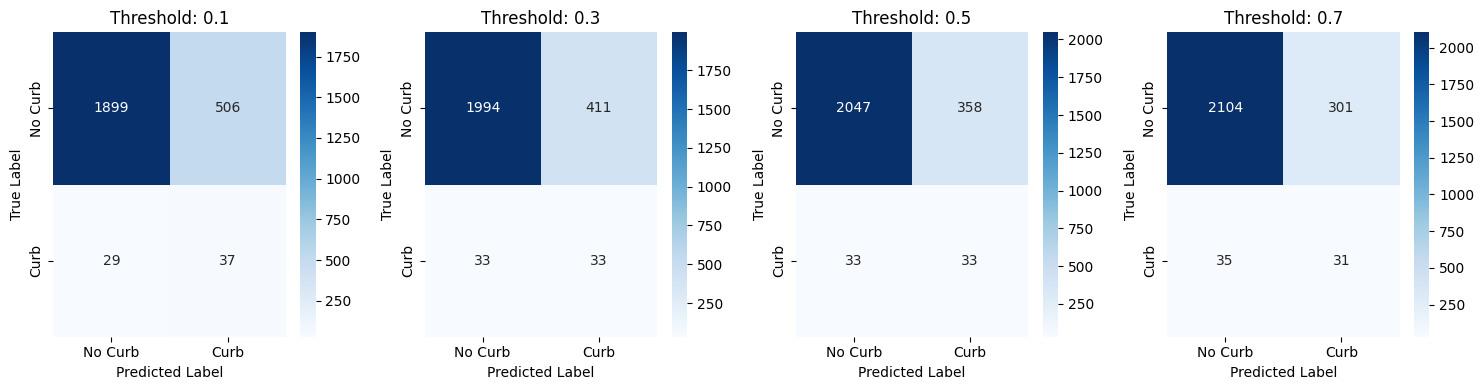


Summary Comparison
Threshold 0.1: Accuracy=0.7835, Precision=0.0681, Recall=0.5606
Threshold 0.3: Accuracy=0.8203, Precision=0.0743, Recall=0.5000
Threshold 0.5: Accuracy=0.8418, Precision=0.0844, Recall=0.5000
Threshold 0.7: Accuracy=0.8640, Precision=0.0934, Recall=0.4697


In [24]:
# Load model
full_eval_best_model_real_world_file_name = "../../models/1s_100hz_unbalanced/20251125-142243_simclr_full_eval.keras"
full_eval_best_model = tf.keras.models.load_model(full_eval_best_model_real_world_file_name)

# Get predictions
predictions = full_eval_best_model.predict(data_normalized)

# Test different thresholds
thresholds = [0.1,0.3, 0.5, 0.7]
results = {}

fig, axes = plt.subplots(1, len(thresholds), figsize=(15, 4))

for idx, threshold in enumerate(thresholds):
    # Convert predictions to binary labels using threshold
    binary_predictions = (predictions[:, 1] >= threshold).astype(int)
    
    # Generate confusion matrix
    cm = confusion_matrix(labels, binary_predictions)
    
    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    results[threshold] = {
        'confusion_matrix': cm,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp
    }
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=['No Curb', 'Curb'],
                yticklabels=['No Curb', 'Curb'])
    axes[idx].set_title(f'Threshold: {threshold}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Print summary comparison
print(f"\n{'='*50}")
print("Summary Comparison")
print(f"{'='*50}")
for threshold in thresholds:
    print(f"Threshold {threshold}: Accuracy={results[threshold]['accuracy']:.4f}, Precision={results[threshold]['precision']:.4f}, Recall={results[threshold]['recall']:.4f}")

## 3. Analyses

In [10]:
# Create a detailed DataFrame for all segments with predictions and segment info
all_segments_details = []

for idx in range(len(labels)):
    segment_detail = {
        'Index': idx,
        'True Label': labels[idx],
        'Predicted Label': binary_predictions[idx],
        'Prediction Score (Class 0)': predictions[idx, 0],
        'Prediction Score (Class 1)': predictions[idx, 1],
        'Start Time': segment_info[idx]['start_time'],
        'End Time': segment_info[idx]['end_time']
    }
    
    all_segments_details.append(segment_detail)

# Convert to DataFrame
df_all_segments = pd.DataFrame(all_segments_details)

# Display the DataFrame
print(f"Total segments: {len(df_all_segments)}")
print(f"\nDataFrame shape: {df_all_segments.shape}")
print(f"\nColumns: {df_all_segments.columns.tolist()}")
print(f"\nFirst 10 rows:")
print(df_all_segments.head(10))

# # Save to CSV
# df_all_segments.to_csv('../../data/Field_validation/all_segments_with_predictions_100hz.csv', index=False)

Total segments: 2471

DataFrame shape: (2471, 7)

Columns: ['Index', 'True Label', 'Predicted Label', 'Prediction Score (Class 0)', 'Prediction Score (Class 1)', 'Start Time', 'End Time']

First 10 rows:
   Index  True Label  Predicted Label  Prediction Score (Class 0)  \
0      0         0.0                0                    0.998131   
1      1         0.0                0                    0.999436   
2      2         0.0                0                    0.998674   
3      3         0.0                0                    0.999953   
4      4         0.0                0                    0.999612   
5      5         0.0                0                    0.989005   
6      6         0.0                0                    0.999463   
7      7         0.0                0                    0.999313   
8      8         0.0                0                    0.999335   
9      9         0.0                0                    0.999332   

   Prediction Score (Class 1)       

Number of False Positives: 309

False Positive Indices:
[ 228  236  244  252  254  275  296  327  333  341  343  350  354  356
  359  426  427  428  439  458  471  476  486  495  496  514  534  536
  541  547  589  591  624  633  638  659  688  693  701  706  710  714
  724  758  760  767  840  860  861  862  863  864  865  866  867  941
  970  980  982  985 1003 1030 1035 1076 1085 1093 1095 1096 1102 1103
 1105 1113 1115 1124 1127 1129 1131 1134 1147 1153 1157 1158 1162 1170
 1182 1183 1186 1200 1209 1214 1216 1220 1228 1245 1252 1256 1258 1259
 1278 1288 1334 1338 1339 1341 1342 1346 1347 1349 1351 1352 1354 1355
 1357 1359 1360 1361 1366 1368 1369 1370 1371 1372 1373 1374 1376 1377
 1378 1379 1381 1382 1383 1384 1385 1387 1388 1389 1390 1392 1393 1394
 1395 1396 1397 1398 1400 1402 1403 1404 1405 1413 1418 1421 1422 1423
 1424 1425 1431 1436 1438 1440 1441 1448 1503 1505 1506 1512 1516 1519
 1521 1524 1526 1527 1529 1530 1533 1540 1546 1548 1551 1581 1595 1605
 1609 1611 1615 1647 

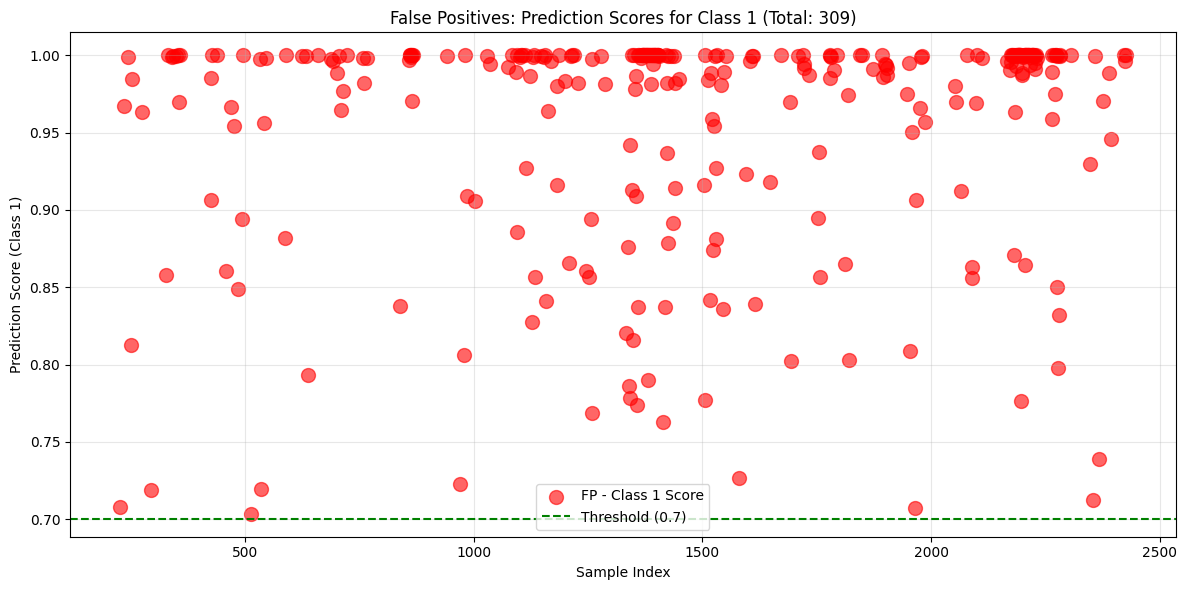

In [12]:
# Use threshold 0.5 (you can change this)
threshold = 0.7
binary_predictions = (predictions[:, 1] >= threshold).astype(int)

# # Find False Negatives: True label is 1, but predicted as 0
# fn_indices = np.where((labels == 1) & (binary_predictions == 0))[0]
# # Find True Positives: True label is 1, but predicted as 1
# tp_indices = np.where((labels == 1) & (binary_predictions == 1))[0]
# Find False Positives: True label is 0, but predicted as 1
fp_indices = np.where((labels == 0) & (binary_predictions == 1))[0]

print(f"Number of False Positives: {len(fp_indices)}")
print(f"\nFalse Positive Indices:")
print(fp_indices)

# Create a detailed DataFrame for False Positives
fp_details = []
for idx in fp_indices:
    fp_details.append({
        'Index': idx,
        'True Label': labels[idx],
        'Predicted Label': binary_predictions[idx],
        'Prediction Score (Class 0)': predictions[idx, 0],
        'Prediction Score (Class 1)': predictions[idx, 1],
        'Start Time': segment_info[idx]['start_time'],
        'End Time': segment_info[idx]['end_time']
    })

fp_df = pd.DataFrame(fp_details)
print(f"\nDetailed False Positive Information:")
print(fp_df)

# Visualize prediction scores for False Positives
plt.figure(figsize=(12, 6))
plt.scatter(fp_indices, predictions[fp_indices, 1], c='red', label='FP - Class 1 Score', alpha=0.6, s=100)
plt.axhline(y=threshold, color='green', linestyle='--', label=f'Threshold ({threshold})')
plt.xlabel('Sample Index')
plt.ylabel('Prediction Score (Class 1)')
plt.title(f'False Positives: Prediction Scores for Class 1 (Total: {len(fp_indices)})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [14]:
df_video = pd.read_csv('../../data/Field_validation/raw_data/video.csv')
df_video.head()

,NTP,Timestamp,Video,X,Y,Z
0,"2025-10-21, 15:15:42.0410","2025-10-21, 15:15:42.0390",00:00:00.104,-0.161850,-0.621307,-0.760971
1,"2025-10-21, 15:15:42.0420","2025-10-21, 15:15:42.0410",00:00:00.105,-0.166687,-0.623611,-0.760941
2,"2025-10-21, 15:15:42.0490","2025-10-21, 15:15:42.0480",00:00:00.112,-0.161774,-0.620071,-0.765106
3,"2025-10-21, 15:15:42.0520","2025-10-21, 15:15:42.0500",00:00:00.114,-0.156738,-0.621979,-0.765808
4,"2025-10-21, 15:15:42.0530","2025-10-21, 15:15:42.0520",00:00:00.116,-0.152634,-0.622070,-0.766769


In [15]:
# get video positions for each false positive
fp_df = match_false_negatives_to_video(fp_df, df_video, buffer_seconds=0.1)
print(fp_df[['Index', 'Start Time', 'video', 'matched_ntp', 'time_diff']])

c:\Users\liuzi\Desktop\Code\Bachelorarbeit\Bachelorarbeit\notebooks\training\../..\utils\analyse.py:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '00:03:46.408' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fn.at[idx, 'video'] = best['Video']
c:\Users\liuzi\Desktop\Code\Bachelorarbeit\Bachelorarbeit\notebooks\training\../..\utils\analyse.py:37: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2025-10-21 15:19:28.345000' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fn.at[idx, 'matched_ntp'] = best['NTP']
c:\Users\liuzi\Desktop\Code\Bachelorarbeit\Bachelorarbeit\notebooks\training\../..\utils\analyse.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Va

     Index              Start Time         video                 matched_ntp  \
0      228 2025-10-21 15:19:28.350  00:03:46.408  2025-10-21 15:19:28.345000   
1      236 2025-10-21 15:19:36.350  00:03:54.410  2025-10-21 15:19:36.347000   
2      244 2025-10-21 15:19:44.350  00:04:02.412  2025-10-21 15:19:44.350000   
3      252 2025-10-21 15:19:52.350  00:04:10.414  2025-10-21 15:19:52.352000   
4      254 2025-10-21 15:19:54.350  00:04:12.408  2025-10-21 15:19:54.345000   
..     ...                     ...           ...                         ...   
304   2389 2025-10-21 15:55:29.350  00:39:47.414  2025-10-21 15:55:29.351000   
305   2393 2025-10-21 15:55:33.350  00:39:51.410  2025-10-21 15:55:33.347000   
306   2421 2025-10-21 15:56:01.350  00:40:19.409  2025-10-21 15:56:01.347000   
307   2424 2025-10-21 15:56:04.350  00:40:22.409  2025-10-21 15:56:04.346000   
308   2425 2025-10-21 15:56:05.350  00:40:23.416  2025-10-21 15:56:05.353000   

                  time_diff  
0    0 da

In [16]:
fp_df.to_csv('../../data/Field_validation/false_positives_100hz_with_video.csv', index=False)

## Extra: t-SNE Plots

In [17]:
import sklearn.manifold
import seaborn as sns

In [18]:


perplexity = 30.0

# Then extract the intermediate model
intermediate_model = simclr_models.extract_intermediate_model_from_base_model(full_eval_best_model, intermediate_layer=7)
intermediate_model.summary()

# Continue with your t-SNE code
embeddings = intermediate_model.predict(data_normalized, batch_size=600)
tsne_model = sklearn.manifold.TSNE(perplexity=perplexity, verbose=1, random_state=42)
tsne_projections = tsne_model.fit_transform(embeddings)

Model: "TPN_layer_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 100, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 100, 32)        │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 100, 64)        │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 100, 96)        │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 96)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,416 (329.75 KB)

 Trainable params: 49,248 (192.38 KB)

 Non-trainable params: 35,168 (137.38 KB)

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(600, 100, 3))
  warnings.warn(msg)
c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 100, 3))
  warnings.warn(msg)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2471 samples in 0.001s...


c:\Users\liuzi\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\liuzi\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


[t-SNE] Computed neighbors for 2471 samples in 0.431s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2471
[t-SNE] Computed conditional probabilities for sample 2000 / 2471
[t-SNE] Computed conditional probabilities for sample 2471 / 2471
[t-SNE] Mean sigma: 1.187956
[t-SNE] KL divergence after 250 iterations with early exaggeration: 70.591728
[t-SNE] KL divergence after 1000 iterations: 1.216127


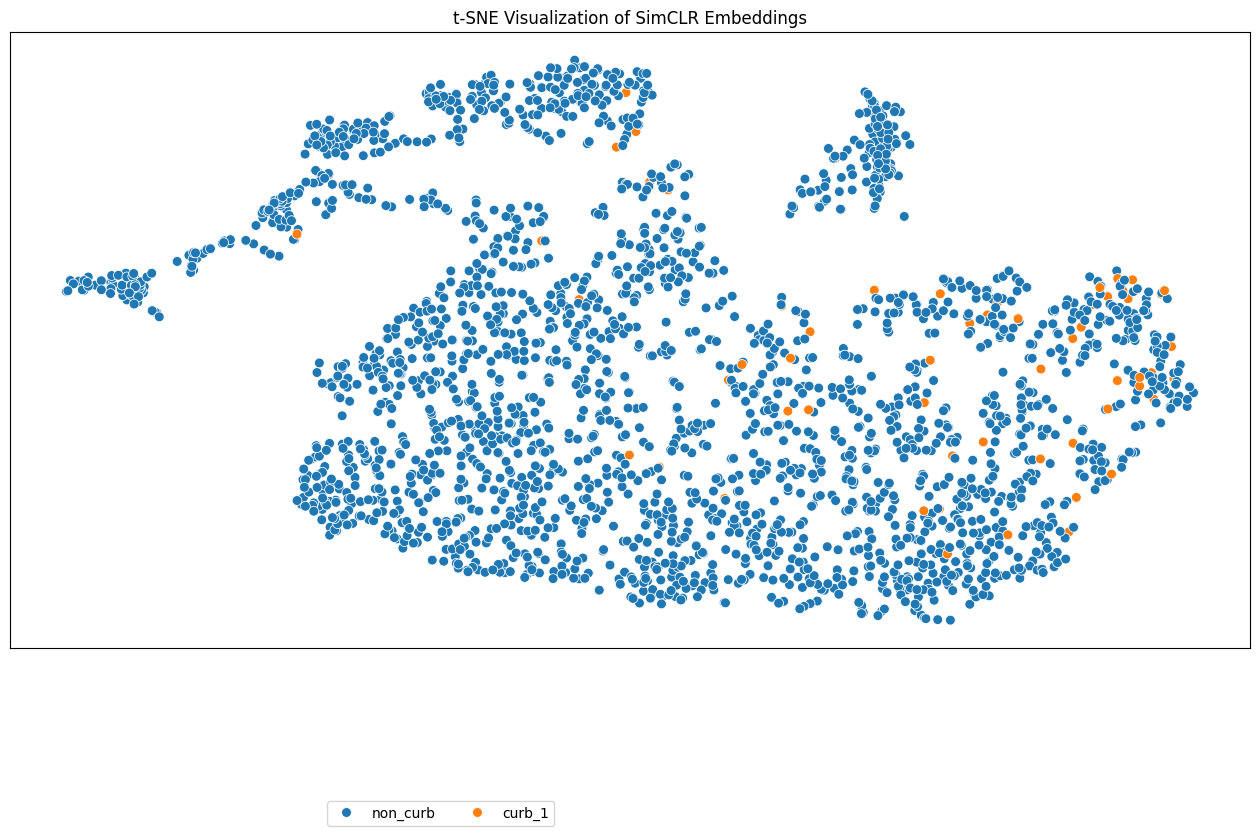

In [19]:
# Define colors
other_class_color = "#1f77b4"  # Blue
curb_1_color = "#ff7f0e"      # Yellow

# Get the true labels (class indices) from the one-hot encoded test labels
labels_argmax = np.argmax(labels_one_hot, axis=1)
unique_labels = np.unique(labels_argmax)

# Create custom color palette
custom_palette = [other_class_color, curb_1_color]  # First color for non_curb (0), second for curb_1 (1)

# Create the t-SNE visualization
plt.figure(figsize=(16,8))
graph = sns.scatterplot(
    x=tsne_projections[:,0], y=tsne_projections[:,1],
    hue=labels_argmax,
    palette=custom_palette,  # Use custom palette instead of "hsv"
    s=50,
    alpha=1.0,
    rasterized=True
)
plt.xticks([], [])
plt.yticks([], [])

plt.title("t-SNE Visualization of SimCLR Embeddings")

# Define your activity names
label_list_full_name = ["non_curb", "curb_1"]

# Update legend with custom colors
try:
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)
    legend = graph.legend_
    if 'label_list_full_name' in globals():
        for j, label in enumerate(unique_labels):
            if label < len(label_list_full_name):
                legend.get_texts()[j].set_text(label_list_full_name[label])
except Exception as e:
    print(f"Warning: Could not customize legend - {e}")
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)